#### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


#### Load Dataset

In [3]:


file_path = "../data/raw/population_processed.csv"

df = pd.read_csv(file_path)
df.head()


,REF_DATE,GEO,DGUID,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1946-01,Canada,2016A000011124,Persons,249,units,0,v1,1,12188000,NaN,NaN,NaN,0
1,1946-04,Canada,2016A000011124,Persons,249,units,0,v1,1,12241000,NaN,NaN,NaN,0
2,1946-07,Canada,2016A000011124,Persons,249,units,0,v1,1,12316000,NaN,NaN,NaN,0
3,1946-10,Canada,2016A000011124,Persons,249,units,0,v1,1,12393000,NaN,NaN,NaN,0
4,1947-01,Canada,2016A000011124,Persons,249,units,0,v1,1,12450000,NaN,NaN,NaN,0


#### Clean column names

In [4]:
df.columns = df.columns.str.lower().str.strip()
df.columns


Index(['ref_date', 'geo', 'dguid', 'uom', 'uom_id', 'scalar_factor',
       'scalar_id', 'vector', 'coordinate', 'value', 'status', 'symbol',
       'terminated', 'decimals'],
      dtype='object')

#### Filter ONLY Canada

In [5]:
df = df[df["geo"] == "Canada"].copy()
df.shape


(306, 14)

#### Convert REF_DATE → datetime & extract year

In [6]:
df["ref_date"] = pd.to_datetime(df["ref_date"])
df["year"] = df["ref_date"].dt.year


#### Convert VALUE → numeric

In [7]:
df["value"] = pd.to_numeric(df["value"], errors="coerce")


#### Handle missing values

In [8]:
df.isna().sum()


ref_date           0
geo                0
dguid              0
uom                0
uom_id             0
scalar_factor      0
scalar_id          0
vector             0
coordinate         0
value              0
status           306
symbol           306
terminated       306
decimals           0
year               0
dtype: int64

Fill (quarterly data)

In [9]:
df["value"] = df["value"].ffill().bfill()


#### Convert quarterly → yearly population

In [10]:
df_yearly = (
    df.sort_values("ref_date")
      .groupby("year")["value"]
      .last()
      .reset_index()
)

df_yearly.rename(columns={"value": "population"}, inplace=True)
df_yearly.head()


,year,population
0,1946,12393000
1,1947,12646000
2,1948,12930000
3,1949,13548000
4,1950,13807000


#### Save cleaned population dataset

In [11]:
output_path = "../data/processed/canada_population_yearly.csv"
df_yearly.to_csv(output_path, index=False)

print("Saved to:", output_path)


Saved to: ../data/processed/canada_population_yearly.csv


#### Summary statistics

In [12]:
df_yearly.describe()


,year,population
count,77.000000,7.700000e+01
mean,1984.000000,2.572312e+07
std,22.371857,7.462379e+06
min,1946.000000,1.239300e+07
25%,1965.000000,1.977700e+07
50%,1984.000000,2.567767e+07
75%,2003.000000,3.173787e+07
max,2022.000000,3.865474e+07


#### Population line plot

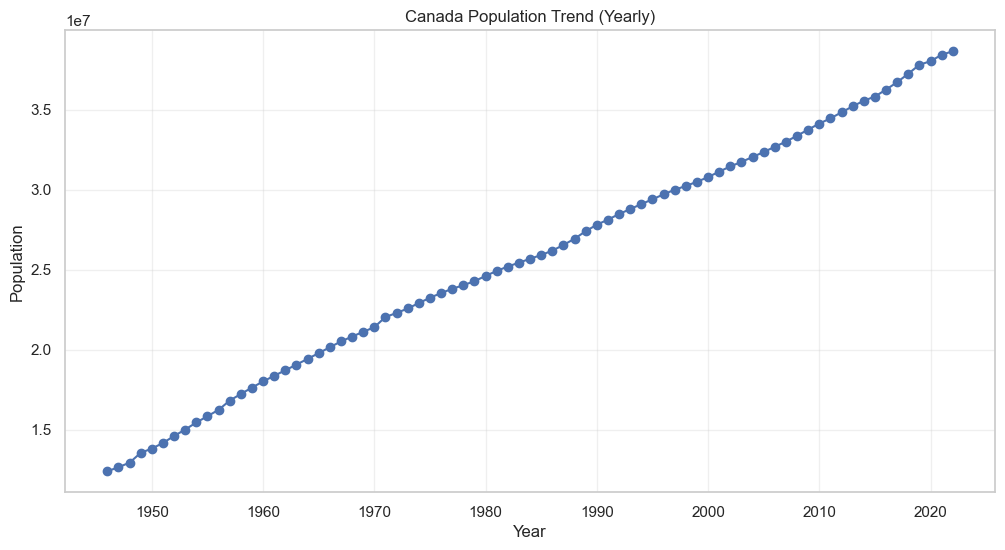

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df_yearly["year"], df_yearly["population"], marker="o")
plt.title("Canada Population Trend (Yearly)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True, alpha=0.3)
plt.show()


#### Population Distribution (Histogram)

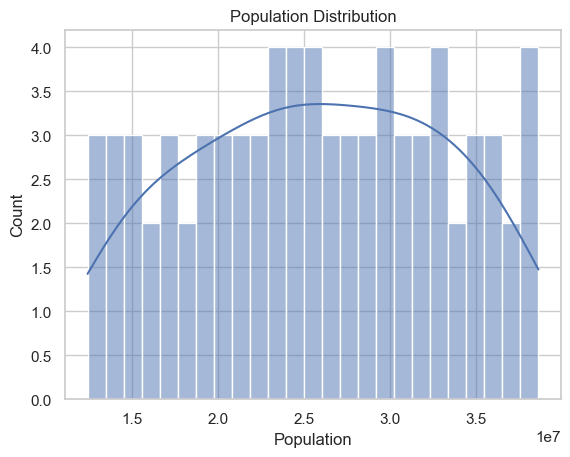

In [14]:
sns.histplot(df_yearly["population"], kde=True, bins=25)
plt.title("Population Distribution")
plt.xlabel("Population")
plt.show()


#### Outlier Detection Using IQR Method

To identify unusual population values, we use the Interquartile Range (IQR) method.
IQR helps us detect values that are significantly lower or higher than the typical range.

Q1 = 25th percentile

Q3 = 75th percentile

IQR = Q3 – Q1

Any value outside Q1 − 1.5 × IQR or Q3 + 1.5 × IQR is considered an outlier.

In [16]:
Q1 = df_yearly["population"].quantile(0.25)
Q3 = df_yearly["population"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_yearly[
    (df_yearly["population"] < lower) | 
    (df_yearly["population"] > upper)
]

outliers


,year,population
